In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("../data/Mobile Reviews Sentiment null.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (50000, 22)


,review_id,customer_name,age,brand,model,price_usd,price_local,currency,exchange_rate_to_usd,rating,...,language,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,source
0,1,Aryan Maharaj,45,Realme,Realme 12 Pro,337.31,₹27996.73,INR,83.00,2.0,...,Hindi,11/6/2023,True,1,1,3,2,1,1,Amazon
1,2,Davi Miguel Sousa,18,Realme,Realme 12 Pro,307.78,R$1754.35,BRL,5.70,4.0,...,Portuguese,3/30/2023,True,3,2,4,3,2,5,Flipkart
2,3,Pahal Balay,27,Google,Pixel 6,864.53,₹71755.99,INR,83.00,4.0,...,Hindi,12/7/2022,True,3,5,3,2,4,8,AliExpress
3,4,David Guzman,19,Xiaomi,Redmi Note 13,660.94,د.إ2425.65,AED,3.67,3.0,...,English,3/11/2025,False,1,3,2,1,2,3,Amazon
4,5,Yago Leão,38,Motorola,Edge 50,792.13,R$4515.14,BRL,5.70,3.0,...,Portuguese,9/29/2023,True,3,3,2,2,1,0,BestBuy


In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Dataset Shape:
(50000, 22)

Column Names:
['review_id', 'customer_name', 'age', 'brand', 'model', 'price_usd', 'price_local', 'currency', 'exchange_rate_to_usd', 'rating', 'sentiment', 'country', 'language', 'review_date', 'verified_purchase', 'battery_life_rating', 'camera_rating', 'performance_rating', 'design_rating', 'display_rating', 'helpful_votes', 'source']

Data Types:
review_id                 int64
customer_name               str
age                       int64
brand                       str
model                       str
price_usd               float64
price_local                 str
currency                    str
exchange_rate_to_usd    float64
rating                  float64
sentiment                   str
country                     str
language                    str
review_date                 str
verified_purchase          bool
battery_life_rating       int64
camera_rating             int64
performance_rating        int64
design_rating             int64
display_rat

In [4]:
# Statistical summary of numerical columns

df.describe().T

,count,mean,std,min,25%,50%,75%,max
review_id,50000.0,25000.500000,14433.901067,1.00,12500.750,25000.500,37500.2500,50000.00
age,50000.0,30.075220,8.931307,18.00,23.000,29.000,36.0000,65.00
price_usd,47550.0,689.892770,310.327220,180.02,450.755,637.585,901.4575,1499.89
exchange_rate_to_usd,50000.0,12.057946,26.553332,0.78,1.000,1.530,5.7000,83.00
rating,47547.0,3.123415,1.249067,1.00,2.000,3.000,4.0000,5.00
battery_life_rating,50000.0,2.718000,1.348270,1.00,1.000,3.000,4.0000,5.00
camera_rating,50000.0,2.717640,1.345001,1.00,1.000,3.000,4.0000,5.00
performance_rating,50000.0,2.719620,1.349208,1.00,1.000,3.000,4.0000,5.00
design_rating,50000.0,2.713960,1.343346,1.00,1.000,3.000,4.0000,5.00
display_rating,50000.0,2.721280,1.352121,1.00,1.000,3.000,4.0000,5.00


In [5]:
# Unique values in important categorical columns

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{col}:")
    print("Unique values:", df[col].nunique())
    print(df[col].dropna().unique()[:15])


customer_name:
Unique values: 45911
<ArrowStringArray>
[     'Aryan Maharaj',  'Davi Miguel Sousa',        'Pahal Balay',
       'David Guzman',          'Yago Leão',         'Lara Abreu',
         'Gina Moore',       'James Howard',      'Rosalia Beyer',
       'Valerie Gray', 'Aimee Hurst-Taylor',   'Benjamin Stanley',
         'Igor Brito',          'Mark Diaz', 'Ms Hollie Phillips']
Length: 15, dtype: str

brand:
Unique values: 7
<ArrowStringArray>
['Realme', 'Google', 'Xiaomi', 'Motorola', 'Apple', 'OnePlus', 'Samsung']
Length: 7, dtype: str

model:
Unique values: 22
<ArrowStringArray>
[  'Realme 12 Pro',         'Pixel 6',   'Redmi Note 13',         'Edge 50',
       'iPhone 14',      'OnePlus 12',       'iPhone SE',  'OnePlus Nord 3',
       'Mi 13 Pro',    'Moto G Power', 'Realme Narzo 70',  'Galaxy Note 20',
        'Pixel 7a',         'Razr 40',         'Poco X6']
Length: 15, dtype: str

price_local:
Unique values: 46127
<ArrowStringArray>
[ '₹27996.73',  'R$1754.35',  '₹717

In [6]:
# ============================================
# Step 4: Missing Value Analysis
# ============================================

missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df)) * 100
})

missing = missing[missing["Missing_Count"] > 0].sort_values(
    "Missing_Count",
    ascending=False
)

missing

,Missing_Count,Missing_Percentage
rating,2453,4.906
price_usd,2450,4.900
source,2448,4.896
sentiment,2445,4.890
price_local,2431,4.862


In [7]:
# Check duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)
print("Number of unique rows:", len(df.drop_duplicates()))

Number of duplicate rows: 0
Number of unique rows: 50000


In [8]:
# Check duplicate review IDs

duplicate_review_ids = df["review_id"].duplicated().sum()

print("Duplicate review IDs:", duplicate_review_ids)

Duplicate review IDs: 0


In [ ]:
# ============================================
# Data Cleaning
# ============================================

df_clean = df.copy()

# 1. Convert review_date to datetime
df_clean["review_date"] = pd.to_datetime(
    df_clean["review_date"],
    errors="coerce"
)

# 2. Convert price_local to numeric
# Extract numeric value from strings such as "$1,234.56"
df_clean["price_local_numeric"] = (
    df_clean["price_local"]
    .astype(str)
    .str.replace(r"[^0-9.\-]", "", regex=True)
)

df_clean["price_local_numeric"] = pd.to_numeric(
    df_clean["price_local_numeric"],
    errors="coerce"
)

# 3. Fill numerical missing values using median
numeric_fill_columns = [
    "rating",
    "price_usd",
    "price_local_numeric"
]

for col in numeric_fill_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# 4. Fill categorical missing values using mode
categorical_fill_columns = [
    "sentiment",
    "source"
]

for col in categorical_fill_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# 5. Verify remaining missing values
print("Remaining missing values:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

print("\nCleaned dataset shape:", df_clean.shape)

Remaining missing values:
price_local    2431
dtype: int64

Cleaned dataset shape: (50000, 23)


In [11]:
# ============================================
#Finalize Clean Dataset
# ============================================

# Drop the original string-based price_local column
df_clean = df_clean.drop(columns=["price_local"])

# Verify missing values
remaining_missing = df_clean.isnull().sum()

print("Remaining missing values:")
print(remaining_missing[remaining_missing > 0])

print("\nFinal cleaned dataset shape:", df_clean.shape)

Remaining missing values:
Series([], dtype: int64)

Final cleaned dataset shape: (50000, 22)


In [12]:
df_clean.head()

,review_id,customer_name,age,brand,model,price_usd,currency,exchange_rate_to_usd,rating,sentiment,...,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,source,price_local_numeric
0,1,Aryan Maharaj,45,Realme,Realme 12 Pro,337.31,INR,83.00,2.0,Negative,...,2023-11-06,True,1,1,3,2,1,1,Amazon,27996.73
1,2,Davi Miguel Sousa,18,Realme,Realme 12 Pro,307.78,BRL,5.70,4.0,Positive,...,2023-03-30,True,3,2,4,3,2,5,Flipkart,1754.35
2,3,Pahal Balay,27,Google,Pixel 6,864.53,INR,83.00,4.0,Positive,...,2022-12-07,True,3,5,3,2,4,8,AliExpress,71755.99
3,4,David Guzman,19,Xiaomi,Redmi Note 13,660.94,AED,3.67,3.0,Positive,...,2025-03-11,False,1,3,2,1,2,3,Amazon,923.58
4,5,Yago Leão,38,Motorola,Edge 50,792.13,BRL,5.70,3.0,Neutral,...,2023-09-29,True,3,3,2,2,1,0,BestBuy,4515.14


brand
Xiaomi      7241
Google      7234
Apple       7144
OnePlus     7136
Realme      7132
Motorola    7061
Samsung     7052
Name: count, dtype: int64


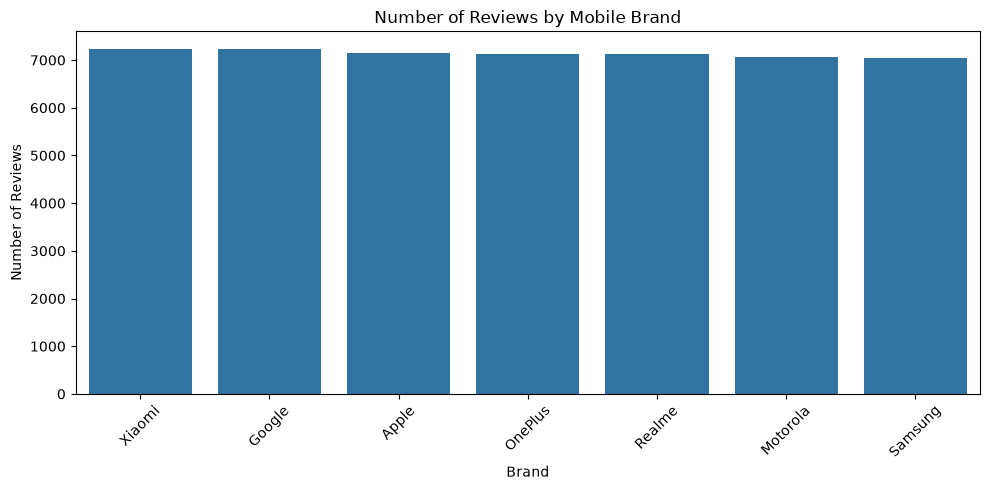

In [13]:
# ============================================
# Step 6.1: Brand Distribution
# ============================================

brand_counts = df_clean["brand"].value_counts()

print(brand_counts)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=brand_counts.index,
    y=brand_counts.values
)

plt.title("Number of Reviews by Mobile Brand")
plt.xlabel("Brand")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

brand
Apple       1080.211223
Samsung      887.753756
Google       797.459574
OnePlus      670.331866
Motorola     512.702461
Xiaomi       458.754478
Realme       405.871000
Name: price_usd, dtype: float64


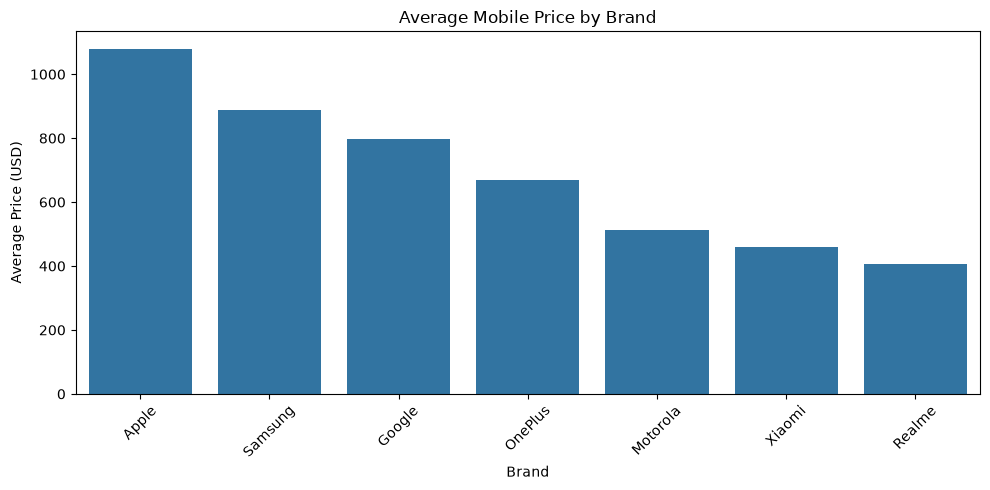

In [14]:
# ============================================
# Step 6.2: Average Price by Brand
# ============================================

avg_price_brand = (
    df_clean.groupby("brand")["price_usd"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_price_brand)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=avg_price_brand.index,
    y=avg_price_brand.values
)

plt.title("Average Mobile Price by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Price (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

brand
Realme      3.130398
OnePlus     3.125701
Apple       3.125560
Google      3.118192
Xiaomi      3.108687
Samsung     3.108196
Motorola    3.104659
Name: rating, dtype: float64


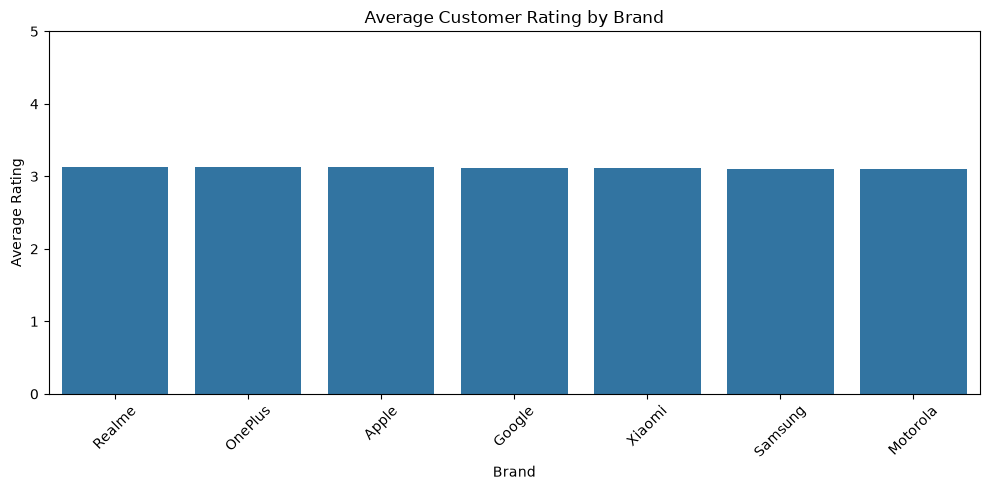

In [15]:
# ============================================
# Step 6.3: Average Rating by Brand
# ============================================

avg_rating_brand = (
    df_clean.groupby("brand")["rating"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_rating_brand)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=avg_rating_brand.index,
    y=avg_rating_brand.values
)

plt.title("Average Customer Rating by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

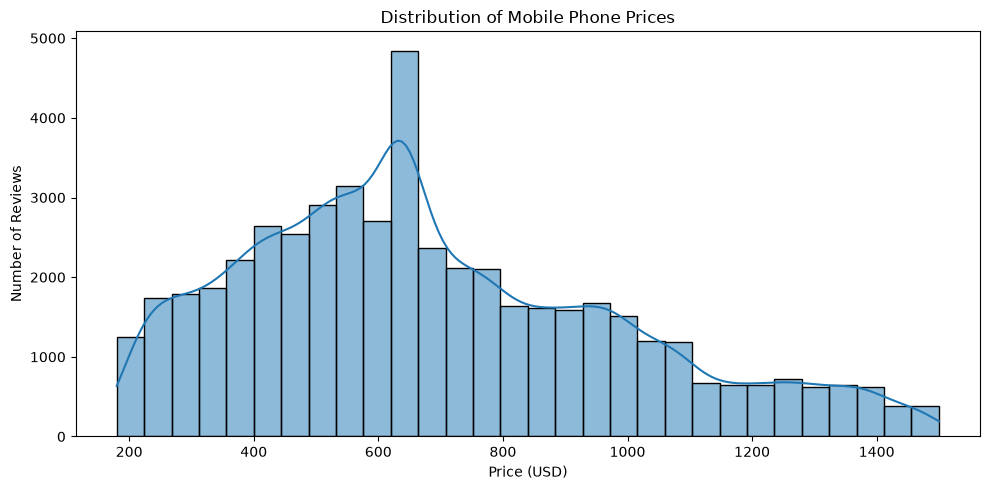

In [16]:
# ============================================
# Step 6.4: Price Distribution
# ============================================

plt.figure(figsize=(10, 5))

sns.histplot(
    df_clean["price_usd"],
    bins=30,
    kde=True
)

plt.title("Distribution of Mobile Phone Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

rating
1.0     6071
2.0     9305
3.0    14309
4.0    13315
5.0     7000
Name: count, dtype: int64


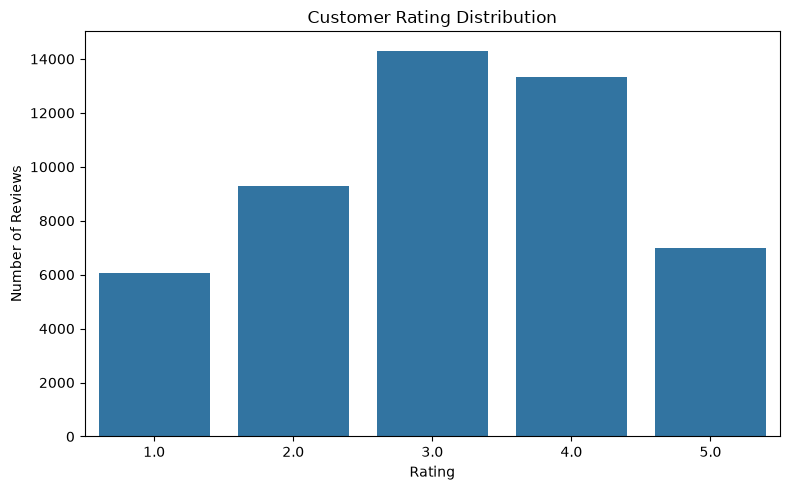

In [17]:
# ============================================
# Step 6.5: Rating Distribution
# ============================================

rating_counts = df_clean["rating"].value_counts().sort_index()

print(rating_counts)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=rating_counts.index,
    y=rating_counts.values
)

plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

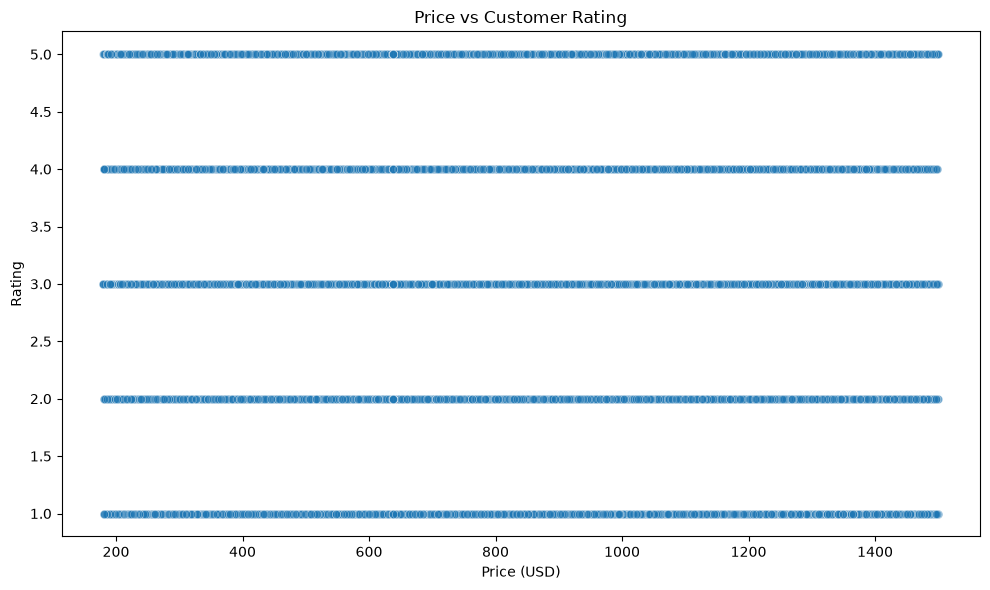

In [18]:
# ============================================
# Step 6.6: Price vs Rating
# ============================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="price_usd",
    y="rating",
    alpha=0.4
)

plt.title("Price vs Customer Rating")
plt.xlabel("Price (USD)")
plt.ylabel("Rating")

plt.tight_layout()
plt.show()

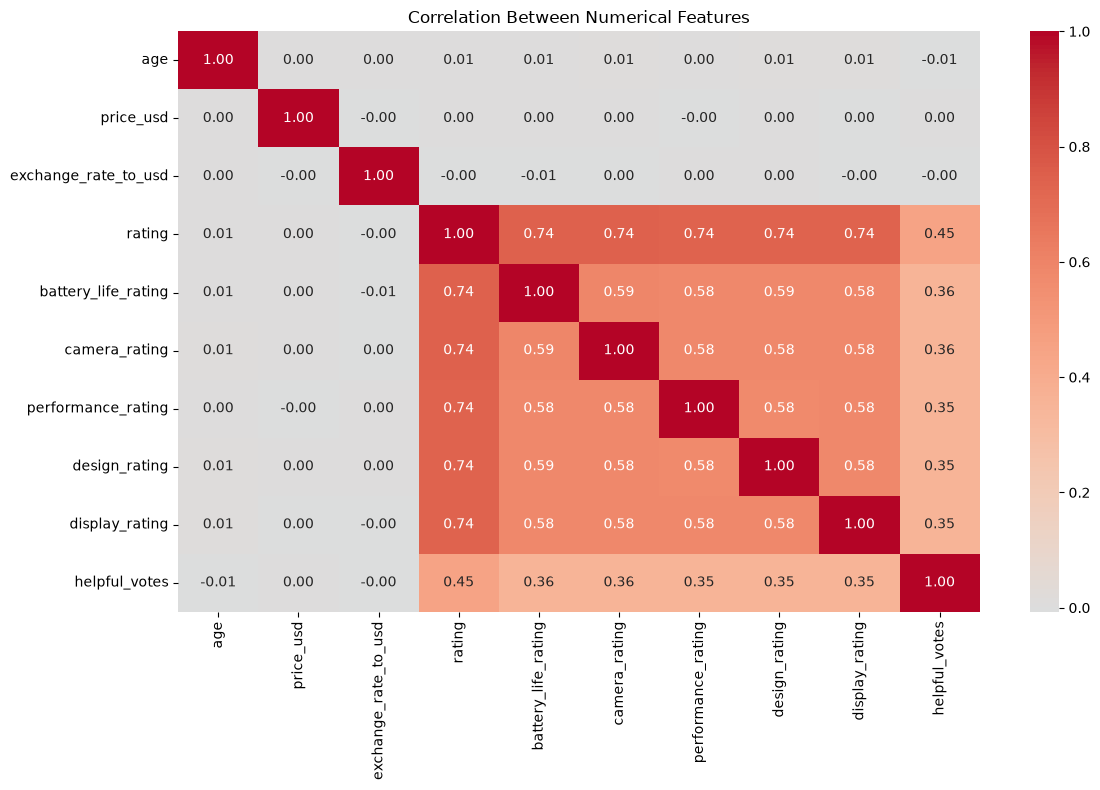

In [19]:
# ============================================
# Step 6.7: Correlation Heatmap
# ============================================

numeric_columns = [
    "age",
    "price_usd",
    "exchange_rate_to_usd",
    "rating",
    "battery_life_rating",
    "camera_rating",
    "performance_rating",
    "design_rating",
    "display_rating",
    "helpful_votes"
]

correlation = df_clean[numeric_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Numerical Features")
plt.tight_layout()
plt.show()

In [20]:
# ============================================
# Step 7: Product-Level Feature Engineering
# ============================================

product_features = (
    df_clean
    .groupby(["brand", "model"])
    .agg(
        price_usd=("price_usd", "mean"),
        average_rating=("rating", "mean"),
        battery_score=("battery_life_rating", "mean"),
        camera_score=("camera_rating", "mean"),
        performance_score=("performance_rating", "mean"),
        design_score=("design_rating", "mean"),
        display_score=("display_rating", "mean"),
        helpful_votes=("helpful_votes", "mean"),
        review_count=("review_id", "count"),
        verified_purchase_ratio=("verified_purchase", "mean")
    )
    .reset_index()
)

print("Number of products:", len(product_features))
print("Number of features:", product_features.shape[1])

product_features.head()

Number of products: 22
Number of features: 12


,brand,model,price_usd,average_rating,battery_score,camera_score,performance_score,design_score,display_score,helpful_votes,review_count,verified_purchase_ratio
0,Apple,iPhone 13,1083.938687,3.150538,2.754952,2.754952,2.765139,2.765139,2.710243,3.743067,1767,0.795133
1,Apple,iPhone 14,1077.610694,3.176174,2.738255,2.781879,2.723714,2.773490,2.758949,3.690716,1788,0.815436
2,Apple,iPhone 15 Pro,1076.756913,3.079197,2.677635,2.707195,2.661461,2.675404,2.691021,3.570552,1793,0.785276
3,Apple,iPhone SE,1082.581434,3.096882,2.727728,2.703786,2.732183,2.690980,2.735523,3.575724,1796,0.796214
4,Google,Pixel 6,801.082415,3.112232,2.712064,2.709962,2.689786,2.706179,2.715427,3.691047,2379,0.800336


In [21]:
# ============================================
# Step 7.1: Overall Quality Score
# ============================================

quality_columns = [
    "battery_score",
    "camera_score",
    "performance_score",
    "design_score",
    "display_score"
]

product_features["overall_quality_score"] = (
    product_features[quality_columns].mean(axis=1)
)

product_features.head()

,brand,model,price_usd,average_rating,battery_score,camera_score,performance_score,design_score,display_score,helpful_votes,review_count,verified_purchase_ratio,overall_quality_score
0,Apple,iPhone 13,1083.938687,3.150538,2.754952,2.754952,2.765139,2.765139,2.710243,3.743067,1767,0.795133,2.750085
1,Apple,iPhone 14,1077.610694,3.176174,2.738255,2.781879,2.723714,2.773490,2.758949,3.690716,1788,0.815436,2.755257
2,Apple,iPhone 15 Pro,1076.756913,3.079197,2.677635,2.707195,2.661461,2.675404,2.691021,3.570552,1793,0.785276,2.682543
3,Apple,iPhone SE,1082.581434,3.096882,2.727728,2.703786,2.732183,2.690980,2.735523,3.575724,1796,0.796214,2.718040
4,Google,Pixel 6,801.082415,3.112232,2.712064,2.709962,2.689786,2.706179,2.715427,3.691047,2379,0.800336,2.706683


In [22]:
# ============================================
# Step 7.2: Positive Sentiment Ratio
# ============================================

positive_ratio = (
    df_clean.assign(
        positive_sentiment=(
            df_clean["sentiment"].str.lower() == "positive"
        ).astype(int)
    )
    .groupby(["brand", "model"])["positive_sentiment"]
    .mean()
    .reset_index(name="positive_sentiment_ratio")
)

product_features = product_features.merge(
    positive_ratio,
    on=["brand", "model"],
    how="left"
)

product_features.head()

,brand,model,price_usd,average_rating,battery_score,camera_score,performance_score,design_score,display_score,helpful_votes,review_count,verified_purchase_ratio,overall_quality_score,positive_sentiment_ratio
0,Apple,iPhone 13,1083.938687,3.150538,2.754952,2.754952,2.765139,2.765139,2.710243,3.743067,1767,0.795133,2.750085,0.587436
1,Apple,iPhone 14,1077.610694,3.176174,2.738255,2.781879,2.723714,2.773490,2.758949,3.690716,1788,0.815436,2.755257,0.593400
2,Apple,iPhone 15 Pro,1076.756913,3.079197,2.677635,2.707195,2.661461,2.675404,2.691021,3.570552,1793,0.785276,2.682543,0.559955
3,Apple,iPhone SE,1082.581434,3.096882,2.727728,2.703786,2.732183,2.690980,2.735523,3.575724,1796,0.796214,2.718040,0.567372
4,Google,Pixel 6,801.082415,3.112232,2.712064,2.709962,2.689786,2.706179,2.715427,3.691047,2379,0.800336,2.706683,0.580496


In [23]:
# ============================================
# Step 8: Feature Selection & Scaling
# ============================================

clustering_features = [
    "price_usd",
    "average_rating",
    "battery_score",
    "camera_score",
    "performance_score",
    "design_score",
    "display_score",
    "helpful_votes",
    "review_count",
    "verified_purchase_ratio",
    "overall_quality_score",
    "positive_sentiment_ratio"
]

X = product_features[clustering_features].copy()

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Original feature shape:", X.shape)
print("Scaled feature shape:", X_scaled.shape)

Original feature shape: (22, 12)
Scaled feature shape: (22, 12)


In [24]:
# ============================================
# Step 9: K-Means Evaluation
# ============================================

inertia = []
silhouette_scores = []

K_range = range(2, 7)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

# Display scores
for k, inertia_value, silhouette_value in zip(
    K_range,
    inertia,
    silhouette_scores
):
    print(
        f"K={k} | "
        f"Inertia={inertia_value:.2f} | "
        f"Silhouette={silhouette_value:.3f}"
    )

K=2 | Inertia=179.62 | Silhouette=0.216
K=3 | Inertia=136.10 | Silhouette=0.236
K=4 | Inertia=119.33 | Silhouette=0.217
K=5 | Inertia=102.55 | Silhouette=0.149
K=6 | Inertia=90.01 | Silhouette=0.151


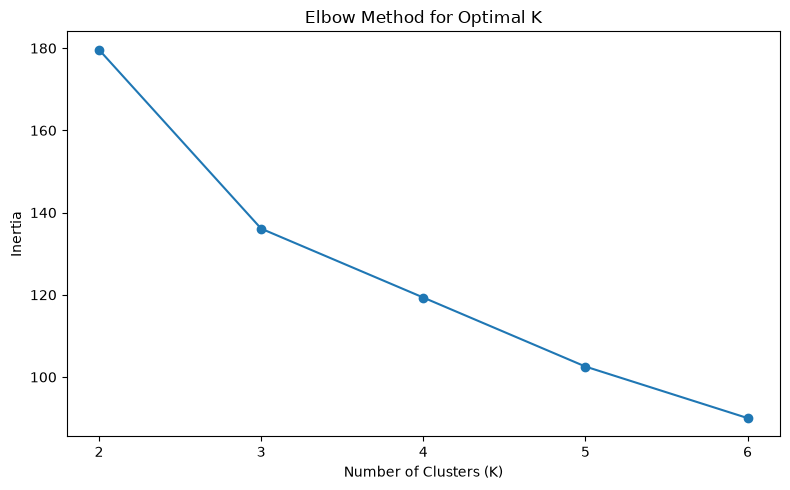

In [25]:
# ============================================
# Elbow Method
# ============================================

plt.figure(figsize=(8, 5))

plt.plot(
    list(K_range),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.xticks(list(K_range))
plt.tight_layout()
plt.show()

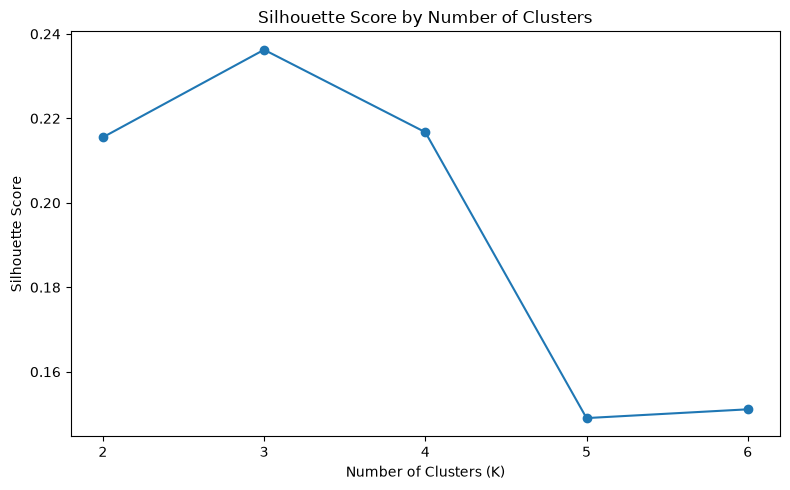

In [26]:
# ============================================
# Silhouette Score
# ============================================

plt.figure(figsize=(8, 5))

plt.plot(
    list(K_range),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.xticks(list(K_range))
plt.tight_layout()
plt.show()

In [27]:
# ============================================
# Step 10: Final K-Means Clustering
# ============================================

optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

product_features["cluster"] = kmeans.fit_predict(X_scaled)

print("K-Means clustering completed!")
print("\nCluster distribution:")
print(product_features["cluster"].value_counts().sort_index())

K-Means clustering completed!

Cluster distribution:
cluster
0     2
1    14
2     3
3     3
Name: count, dtype: int64


In [28]:
# ============================================
# Step 10.1: Cluster Profile Analysis
# ============================================

cluster_profile = (
    product_features
    .groupby("cluster")[clustering_features]
    .mean()
    .round(2)
)

cluster_profile

,price_usd,average_rating,battery_score,camera_score,performance_score,design_score,display_score,helpful_votes,review_count,verified_purchase_ratio,overall_quality_score,positive_sentiment_ratio
cluster,,,,,,,,,,,,
0,405.89,3.13,2.73,2.72,2.75,2.72,2.75,3.67,3566.00,0.8,2.74,0.58
1,663.34,3.11,2.72,2.72,2.72,2.71,2.72,3.63,2298.71,0.8,2.72,0.57
2,1016.44,3.16,2.74,2.76,2.75,2.76,2.73,3.70,1781.33,0.8,2.75,0.59
3,951.10,3.08,2.69,2.68,2.66,2.68,2.67,3.61,1780.67,0.8,2.68,0.57


In [29]:
# ============================================
# Step 10.2: Product Cluster Assignment
# ============================================

product_features[
    [
        "brand",
        "model",
        "price_usd",
        "average_rating",
        "overall_quality_score",
        "cluster"
    ]
].sort_values("cluster")

,brand,model,price_usd,average_rating,overall_quality_score,cluster
13,Realme,Realme 12 Pro,407.677332,3.140594,2.738897,0
14,Realme,Realme Narzo 70,404.095803,3.120378,2.731832,0
3,Apple,iPhone SE,1082.581434,3.096882,2.718040,1
6,Google,Pixel 8,791.928209,3.122748,2.724005,1
7,Motorola,Edge 50,515.415495,3.087257,2.695378,1
8,Motorola,Moto G Power,510.950551,3.122501,2.714590,1
5,Google,Pixel 7a,799.317202,3.119530,2.728768,1
4,Google,Pixel 6,801.082415,3.112232,2.706683,1
11,OnePlus,OnePlus 12,668.509559,3.128713,2.724666,1
10,OnePlus,OnePlus 11R,671.231741,3.112207,2.709166,1


In [30]:
# ============================================
# Step 11: Assign Business Segment Names
# ============================================

segment_names = {
    0: "Value Segment",
    1: "Mid-Range Segment",
    2: "Premium High-Rated Segment",
    3: "Premium Lower-Rated Segment"
}

product_features["segment"] = product_features["cluster"].map(segment_names)

product_features[
    [
        "brand",
        "model",
        "price_usd",
        "average_rating",
        "overall_quality_score",
        "cluster",
        "segment"
    ]
].sort_values("cluster")

,brand,model,price_usd,average_rating,overall_quality_score,cluster,segment
13,Realme,Realme 12 Pro,407.677332,3.140594,2.738897,0,Value Segment
14,Realme,Realme Narzo 70,404.095803,3.120378,2.731832,0,Value Segment
3,Apple,iPhone SE,1082.581434,3.096882,2.718040,1,Mid-Range Segment
6,Google,Pixel 8,791.928209,3.122748,2.724005,1,Mid-Range Segment
7,Motorola,Edge 50,515.415495,3.087257,2.695378,1,Mid-Range Segment
8,Motorola,Moto G Power,510.950551,3.122501,2.714590,1,Mid-Range Segment
5,Google,Pixel 7a,799.317202,3.119530,2.728768,1,Mid-Range Segment
4,Google,Pixel 6,801.082415,3.112232,2.706683,1,Mid-Range Segment
11,OnePlus,OnePlus 12,668.509559,3.128713,2.724666,1,Mid-Range Segment
10,OnePlus,OnePlus 11R,671.231741,3.112207,2.709166,1,Mid-Range Segment


In [31]:
from sklearn.decomposition import PCA

In [32]:
# ============================================
# Step 12: PCA Cluster Visualization
# ============================================

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

product_features["PCA1"] = X_pca[:, 0]
product_features["PCA2"] = X_pca[:, 1]

print(
    "Explained variance:",
    pca.explained_variance_ratio_
)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

Explained variance: [0.50176068 0.16311788]
Total explained variance: 0.6648785620500741


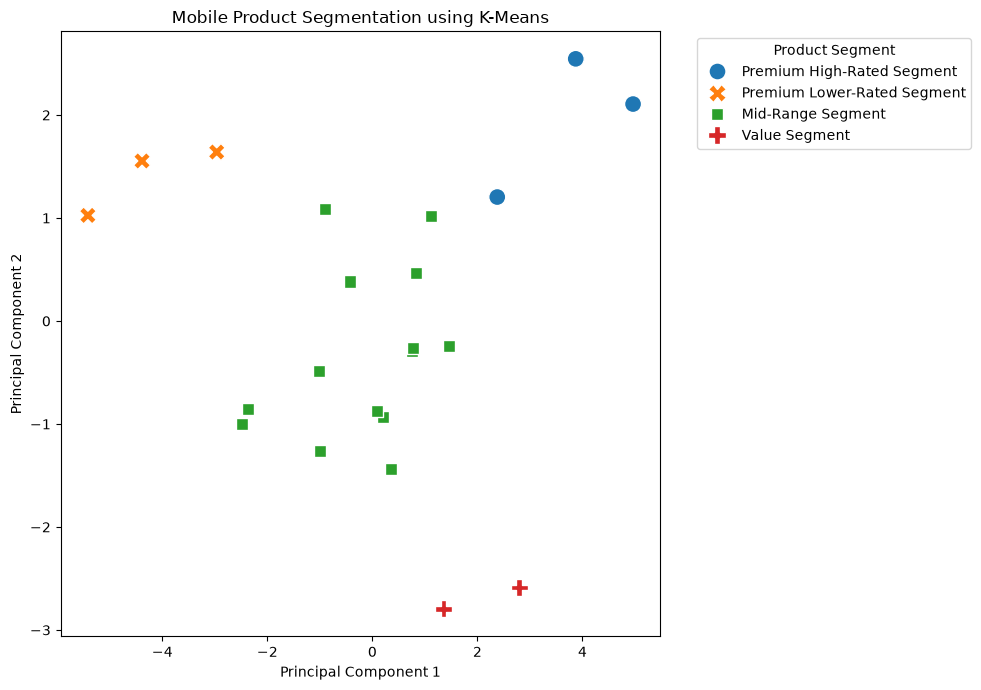

In [33]:
# ============================================
# Step 12.1: Plot Product Segments
# ============================================

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=product_features,
    x="PCA1",
    y="PCA2",
    hue="segment",
    style="segment",
    s=150
)

plt.title("Mobile Product Segmentation using K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(
    title="Product Segment",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [34]:
# ============================================
# Step 12.2: Final Cluster Summary
# ============================================

cluster_summary = (
    product_features
    .groupby("segment")
    .agg(
        product_count=("model", "count"),
        avg_price=("price_usd", "mean"),
        avg_rating=("average_rating", "mean"),
        avg_quality=("overall_quality_score", "mean"),
        avg_helpful_votes=("helpful_votes", "mean"),
        avg_review_count=("review_count", "mean")
    )
    .round(2)
)

cluster_summary

,product_count,avg_price,avg_rating,avg_quality,avg_helpful_votes,avg_review_count
segment,,,,,,
Mid-Range Segment,14,663.34,3.11,2.72,3.63,2298.71
Premium High-Rated Segment,3,1016.44,3.16,2.75,3.70,1781.33
Premium Lower-Rated Segment,3,951.10,3.08,2.68,3.61,1780.67
Value Segment,2,405.89,3.13,2.74,3.67,3566.00


In [35]:
# ============================================
# Step 13: Recommendation System
# ============================================

from sklearn.metrics.pairwise import cosine_similarity

# Calculate similarity between all products
similarity_matrix = cosine_similarity(X_scaled)

print("Similarity matrix shape:", similarity_matrix.shape)

Similarity matrix shape: (22, 22)


In [36]:
# ============================================
# Step 13.1: Recommendation Function
# ============================================

def recommend_products(product_name, n_recommendations=5):
    
    # Find the selected product
    matches = product_features[
        product_features["model"].str.lower() == product_name.lower()
    ]
    
    if matches.empty:
        return f"Product '{product_name}' not found."
    
    product_index = matches.index[0]
    
    # Get similarity scores
    scores = similarity_matrix[product_index]
    
    # Sort by similarity
    similar_indices = scores.argsort()[::-1]
    
    # Remove the selected product itself
    similar_indices = [
        i for i in similar_indices
        if i != product_index
    ]
    
    # Select top recommendations
    top_indices = similar_indices[:n_recommendations]
    
    recommendations = product_features.iloc[top_indices][
        [
            "brand",
            "model",
            "price_usd",
            "average_rating",
            "overall_quality_score",
            "segment"
        ]
    ].copy()
    
    recommendations["similarity_score"] = scores[top_indices]
    
    return recommendations.reset_index(drop=True)

In [37]:
# Test recommendation system

recommend_products("iPhone 13", 5)

,brand,model,price_usd,average_rating,overall_quality_score,segment,similarity_score
0,Samsung,Galaxy Note 20,887.773167,3.144215,2.739966,Premium High-Rated Segment,0.885611
1,Apple,iPhone 14,1077.610694,3.176174,2.755257,Premium High-Rated Segment,0.754482
2,OnePlus,OnePlus 12,668.509559,3.128713,2.724666,Mid-Range Segment,0.544745
3,Samsung,Galaxy Z Flip,886.563025,3.128355,2.730105,Mid-Range Segment,0.499818
4,OnePlus,OnePlus Nord 3,671.190616,3.136555,2.724118,Mid-Range Segment,0.317941


In [38]:
# ============================================
# Step 14: Save ML Results for Streamlit
# ============================================

import joblib

# Save product data
product_features.to_csv(
    "product_features.csv",
    index=False
)

# Save scaler
joblib.dump(
    scaler,
    "scaler.pkl"
)

# Save K-Means model
joblib.dump(
    kmeans,
    "kmeans_model.pkl"
)

# Save similarity matrix
joblib.dump(
    similarity_matrix,
    "similarity_matrix.pkl"
)

# Save clustering feature list
joblib.dump(
    clustering_features,
    "clustering_features.pkl"
)

print("All model files saved successfully!")

All model files saved successfully!
